# Import Statements

In [6]:
import pickle
import numpy as np
import pandas as pd

In [7]:
import copy

In [8]:
import scipy
import sklearn
from scipy.stats import pearsonr
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

In [9]:
from sklearn.preprocessing import OneHotEncoder
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import shap
from math import sqrt
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
import seaborn as sns


In [10]:
from sklearn.linear_model import Lasso

from sklearn.metrics import accuracy_score


In [11]:
import tqdm as notebook_tqdm
from skopt import BayesSearchCV
import skopt
from skopt.space import Real, Categorical, Integer
from sklearn.ensemble import RandomForestRegressor

In [13]:
from platform import python_version

print(python_version())


3.10.12


In [14]:
print(np.__version__)

1.26.3


# Define all functions

In [15]:
#set the parameter space for XGBoost regression
space ={'learning_rate': Real(0.01, 1.0, 'log-uniform'),
        'min_child_weight': Integer(0, 10),
        'max_depth': Integer(0, 50),
        'max_delta_step': Integer(0, 20),
        'subsample': Real(0.01, 1.0, 'uniform'),
        'colsample_bytree': Real(0.01, 1.0, 'uniform'),
        'colsample_bylevel': Real(0.01, 1.0, 'uniform'),
        'reg_lambda': Real(1e-9, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-9, 1.0, 'log-uniform'),
        'gamma': Real(1e-9, 0.5, 'log-uniform'),
        'n_estimators': Integer(50, 200),
        }



# set parameter space for LASSO

lasso_space = {
    'alpha': Real(1e-5, 1.0, 'log-uniform')  # L1 penalty term
}

In [16]:
#callback function to be used later which stops parameter search if it goes above 98% to save time
def on_step(optim_result):
    """
    Callback meant to view scores after
    each iteration while performing Bayesian
    Optimization in Skopt"""
    score = xgb_bayes_search.best_result_['score']
    print("best score: %s" % score)
    if score >= 0.98:
        print('Interrupting!')
        return True

In [17]:
#input training sets to find the best hyperparameters using Bayesian cross-validation for XGBoost model

def bayesian_xgb_search(X, y,space):
    """
    Perform Bayesian hyperparameter tuning for XGBoost using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        xgb.XGBRegressor: Best XGBoost model with tuned parameters.
    """
    xgbreg = xgb.XGBRegressor()
    xgb_bayes_search = BayesSearchCV(
        xgbreg, space, n_iter=50, scoring=None, n_jobs=-1,
        cv=5, verbose=1, random_state=42, n_points=12
    )

    xgb_bayes_search.fit(X, y)
    
    print("Best XGB Parameters:", xgb_bayes_search.best_params_)
    
    best_params = xgb_bayes_search.best_params_
    best_xgbreg = xgb.XGBRegressor(**best_params)

    return best_xgbreg

#TO RUN - best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 


def bayesian_lasso_search(X, y, lasso_space):
    lasso = Lasso(max_iter=100000)
    lasso_bayes_search = BayesSearchCV(
        estimator=lasso,
        search_spaces=lasso_space,
        scoring=None,
        cv=5,
        n_iter=10,  # number of iterations to try
        random_state=42,
        verbose=1,
        n_jobs=-1
)
    lasso_bayes_search.fit(X, y)
    
    print("Best Lasso hyperparameters:", lasso_bayes_search.best_params_)
    
    best_params = lasso_bayes_search.best_params_
    best_lasso = Lasso(**best_params)

    return best_lasso
    

In [18]:
#input full sets except houldout to find the best model using k-fold (10) cross validation which uses the best hyperparametres from the previous step. 

def eval_k_fold(m, X, y, k):
    """
    Evaluates model using k-fold CV and returns the final model trained on full dataset.
    
    Parameters:
    m: model (e.g., XGBoost or RandomForest) with best hyperparameters
    X: feature matrix
    y: labels
    k: number of folds
    """
    cv = KFold(n_splits=k, shuffle=True)
    rmse_results = []
    percent_rmse_results = []
    r2_results = []
 
    low = 100
    best_fold_model = None
    
    for fold, (train, test) in enumerate(cv.split(X, y), start=1):
        print(f"\n=== Fold {fold} ===")
        
        m.fit(X[train], y[train].ravel())
        preds = m.predict(X[test])
        
        ss = sqrt(mean_squared_error(y[test], preds))  
        rr = r2_score(y[test], preds)                  
        mm = np.mean(y[test])
        error_mean = (ss / mm) * 100
        
        rmse_results.append(ss)
        percent_rmse_results.append(error_mean)
        r2_results.append(rr)
        
        print(f"R²: {rr:.4f}, RMSE: {ss:.4f}, %RMSE: {error_mean:.2f}")
        
        if error_mean < low:
            low = error_mean
            best_fold_model = copy.deepcopy(m)
    
    print("\nCV Summary:")
    print(f"Mean %RMSE: {np.mean(percent_rmse_results):.2f} ± {np.std(percent_rmse_results):.2f}")
    
    # Plot %RMSE per fold
    plt.figure(figsize=(8,5), dpi=300)
    cb_palette = ["#E69F00", "#56B4E9", "#009E73"]
    plt.plot(range(1, k+1), percent_rmse_results, marker="o", label="%RMSE", color=cb_palette[0])
    plt.plot(range(1, k+1), rmse_results, marker="s", label="RMSE", color=cb_palette[1])
    plt.plot(range(1, k+1), r2_results, marker="^", label="R²", color=cb_palette[2])
    plt.xlabel("Fold Number")
    plt.ylabel("Metric Value")
    plt.title("Cross-Validation Metrics per Fold")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Retrain the best model on full dataset
    final_model = copy.deepcopy(best_fold_model)
    final_model.fit(X, y.ravel())
    
    metrics = {
        "RMSE": rmse_results,
        "%RMSE": percent_rmse_results,
        "R2": r2_results
    }
    
    return final_model, metrics

#TO RUN - best_model_xgb, results = eval_k_fold(model, X, y, 10)

In [20]:
def plot_xgb_feature_importance(best_model, X_train, top_n=20, savepath=None):
    """
    Computes and plots the feature importance of an XGBoost model based on Gain.

    Parameters:
        best_model (XGBRegressor): Trained XGBoost model from Kfold cross validation.
        X_train (DataFrame): Training feature set used for Kfold CV.
        top_n (int): Number of top features to display. Default is 20.

    Returns:
        DataFrame: DataFrame containing feature importance scores.
    """
    # Generate feature names
    f_names = ['f' + str(i) for i in range(len(X_train.columns))]
    my_dict = best_model.get_booster().get_score(importance_type="gain")

    # Map feature names back to original column names
    new_dict = {X_train.columns[f_names.index(key)]: value for key, value in my_dict.items()}

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(new_dict, orient='index', columns=['F_Score(GAIN)'])

    # Select top N important features
    top_features = df.nlargest(top_n, "F_Score(GAIN)")

    # Plot feature importance
    fig = plt.figure(figsize=(8, 8), dpi=100)
    indexes = top_features.index[::-1]
    values = top_features.values.ravel()[::-1]

    plt.barh(indexes, values)
    plt.title(f'XGBoost Feature Importance for Top {top_n} SNPs')
    plt.ylabel('Features')
    plt.xlabel('Relative F_Score (GAIN)')
    # Save at 600 dpi if path given
    if savepath is not None:
        fig.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()
    
    return df

#TO RUN - feature_importance= plot_xgb_feature_importance(best_model, X_train, top_n=20)

In [21]:
def evaluate_holdout_performance(best_model, X_holdout, y_holdout):
    """
    Evaluates the performance of a models on a holdout dataset.

    Parameters:
        best_model (XGBRegressor or RFR): Trained XGBoost/RF model from Kfold CV.
        X_holdout (DataFrame): Holdout feature set.
        y_holdout (Series or array): Holdout target values.

    Returns:
        dict: Dictionary containing RMSE, R2, and mean error percentage.
    """
    # Generate predictions
    all_preds = best_model.predict(X_holdout)

    # Compute performance metrics (correct argument order)
    ss = sqrt(mean_squared_error(y_holdout, all_preds))
    rr = r2_score(y_holdout, all_preds)
    mm = np.mean(y_holdout)
    error_mean = (ss / mm) * 100
    
    # Print evaluation metrics
    print(f"R^2 Value of Holdout: {rr:.2f}")
    print(f"RMSE of Holdout: {ss:.2f}")
    print(f"Mean of Holdout: {mm:.2f}")
    print(f"This is {error_mean:.2f}% of the mean pheno data")
    
    # data for residual plot
    y_holdout = y_holdout.ravel()
    
    # print first 5 examples
    for i in range(5):
        print(i, y_holdout[i], all_preds[i])
    
    # Create DataFrame for plotting 
    thisplot = pd.DataFrame({
        'actual': y_holdout,
        'predicted': all_preds
    })
    
    # Generate regression plot
    plt.figure(figsize=(8, 6), dpi=300)
    sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
    plt.title('XGBoost Predicted vs Actual')
    plt.show()
    
    return {"RMSE": ss, "R2": rr, "Mean Error %": error_mean}

#TO RUN - metrics = evaluate_holdout_performance(best_model, X_holdout, y_holdout)

In [22]:
def plot_residuals(actual, predicted):
    """
    Plots residuals (Predicted - Actual) as a scatter plot.
    
    Parameters:
        actual (array-like): Array of actual values.
        predicted (array-like): Array of predicted values.
    """
    # Convert to NumPy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Compute residuals (Predicted - Actual)
    residuals = predicted - actual
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    
    # Show the plot
    plt.show()

#TO RUN - Plot_residuals(plot_x, plot_y)

# Load dataset

In [16]:

geno = pd.read_pickle("genotype_data.pkl")

In [17]:
geno.head()

,Data-storage-ID,Gm01_3567,Gm01_3677,Gm01_7345,Gm01_7357,Gm01_8865,Gm01_8876,Gm01_10496,Gm01_11433,Gm01_13491,...,Gm20_50129694,Gm20_50137618,Gm20_50144975,Gm20_50145059,Gm20_50145237,Gm20_50145552,Gm20_50148200,Gm20_50150137,Gm20_50150739,Gm20_50153322
0,AB-01,0,0,0,0,0,0,0,1,1,...,0,1,0,2,0,0,0,0,2,0
1,AB-02,0,0,0,0,0,0,0,1,1,...,2,1,0,0,2,0,0,0,0,2
2,BR-01,0,0,0,0,0,1,0,0,0,...,0,0,0,2,0,0,0,0,2,0
3,BR-02,0,0,0,0,0,1,0,0,0,...,0,1,0,2,0,0,0,0,2,0
4,BR-03,1,0,0,0,0,1,1,0,0,...,2,0,0,0,2,0,0,0,0,2


In [18]:
pheno =  pd.read_pickle("phenotype.pkl")

In [19]:
pheno.head()

,method_name,Data-storage-ID,Origin,new_line,SOJA.EVALUATION.IL989,SOJA.EVALUATION.MS989,SOYBEAN.CHEMICAL.NB.2009,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
0,WILD.SOYBEAN.EVAL.1IL85,PI468918,Liaoning,PI468918_WILD.SOYBEAN.EVAL.1IL85,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,10.0
1,SOJA.EVALUATION.MS989,PI507641,Hyogo,PI507641_SOJA.EVALUATION.MS989,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,10.0
2,SOJA.EVALUATION.MS989,PI562553,Chungcheongbuk-do,PI562553_SOJA.EVALUATION.MS989,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,10.0
3,SOYBEAN.EVALUATION.MS1999_01,USB-128,Iwate,USB-128_SOYBEAN.EVALUATION.MS1999_01,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,10.1
4,SOJA.EVALUATION.MS989,PI407052,Iwate,PI407052_SOJA.EVALUATION.MS989,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,10.1


In [20]:
pheno.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1272 entries, 0 to 1271
Data columns (total 38 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   method_name                   1272 non-null   object 
 1   Data-storage-ID               1272 non-null   object 
 2   Origin                        1272 non-null   object 
 3   new_line                      1272 non-null   object 
 4   SOJA.EVALUATION.IL989         1272 non-null   int64  
 5   SOJA.EVALUATION.MS989         1272 non-null   int64  
 6   SOYBEAN.CHEMICAL.NB.2009      1272 non-null   int64  
 7   SOYBEAN.EVALUATION.1IL64      1272 non-null   int64  
 8   SOYBEAN.EVALUATION.1IL66      1272 non-null   int64  
 9   SOYBEAN.EVALUATION.1MN63      1272 non-null   int64  
 10  SOYBEAN.EVALUATION.2IL81.1    1272 non-null   int64  
 11  SOYBEAN.EVALUATION.2IL81.2    1272 non-null   int64  
 12  SOYBEAN.EVALUATION.2KY81      1272 non-null   int64  
 13  SOY

In [21]:
pheno = pheno.drop(['method_name', 'Origin'], axis=1)

In [22]:
Final_data = pd.merge(geno, pheno, on='Data-storage-ID', how='right', indicator=False)

In [23]:
Final_data.head()

,Data-storage-ID,Gm01_3567,Gm01_3677,Gm01_7345,Gm01_7357,Gm01_8865,Gm01_8876,Gm01_10496,Gm01_11433,Gm01_13491,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
0,PI468918,0,2,1,0,1,0,1,1,2,...,0,0,0,0,0,0,0,0,1,10.0
1,PI507641,0,0,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,10.0
2,PI562553,0,2,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,10.0
3,USB-128,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,10.1
4,PI407052,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,10.1


In [24]:
Final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1272 entries, 0 to 1271
Columns: 538337 entries, Data-storage-ID to seed_oil
dtypes: float64(1), int64(538334), object(2)
memory usage: 5.1+ GB


In [25]:
nan_values = Final_data[Final_data.isna().any(axis=1)] 

In [26]:
nan_values.head()

,Data-storage-ID,Gm01_3567,Gm01_3677,Gm01_7345,Gm01_7357,Gm01_8865,Gm01_8876,Gm01_10496,Gm01_11433,Gm01_13491,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil


In [27]:
Final_data.to_pickle("Full_SNP_set.pkl") 

In [75]:
Final_data = pd.read_pickle("Full_set_chr_data.pkl")
Final_data.head()

,Data-storage-ID,Gm01_3567,Gm01_3677,Gm01_7345,Gm01_7357,Gm01_8865,Gm01_8876,Gm01_10496,Gm01_11433,Gm01_13491,...,SOYBEAN.EVALUATION.MS2001,SOYBEAN.EVALUATION.MS2001,SOYBEAN.EVALUATION.MS2001,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
0,PI468918,0,2,1,0,1,0,1,1,2,...,0,0,0,0,0,0,0,0,1,10.0
1,PI507641,0,0,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,10.0
2,PI562553,0,2,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,10.0
3,USB-128,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,10.1
4,PI407052,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,10.1


In [28]:
Final_data.set_index('new_line', inplace=True)

In [29]:
Final_data.head()

,Data-storage-ID,Gm01_3567,Gm01_3677,Gm01_7345,Gm01_7357,Gm01_8865,Gm01_8876,Gm01_10496,Gm01_11433,Gm01_13491,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
new_line,,,,,,,,,,,,,,,,,,,,,
PI468918_WILD.SOYBEAN.EVAL.1IL85,PI468918,0,2,1,0,1,0,1,1,2,...,0,0,0,0,0,0,0,0,1,10.0
PI507641_SOJA.EVALUATION.MS989,PI507641,0,0,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,10.0
PI562553_SOJA.EVALUATION.MS989,PI562553,0,2,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,10.0
USB-128_SOYBEAN.EVALUATION.MS1999_01,USB-128,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,10.1
PI407052_SOJA.EVALUATION.MS989,PI407052,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,10.1


In [30]:
Final_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1272 entries, PI468918_WILD.SOYBEAN.EVAL.1IL85 to HNY-48_SOJA.EVALUATION.IL989
Columns: 538336 entries, Data-storage-ID to seed_oil
dtypes: float64(1), int64(538334), object(1)
memory usage: 5.1+ GB


In [31]:
#Split dataset into training,test and holdout

In [32]:
snps = Final_data.iloc[:, 0:538335]
snps.head()

,Data-storage-ID,Gm01_3567,Gm01_3677,Gm01_7345,Gm01_7357,Gm01_8865,Gm01_8876,Gm01_10496,Gm01_11433,Gm01_13491,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
new_line,,,,,,,,,,,,,,,,,,,,,
PI468918_WILD.SOYBEAN.EVAL.1IL85,PI468918,0,2,1,0,1,0,1,1,2,...,0,0,0,0,0,0,0,0,0,1
PI507641_SOJA.EVALUATION.MS989,PI507641,0,0,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
PI562553_SOJA.EVALUATION.MS989,PI562553,0,2,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
USB-128_SOYBEAN.EVALUATION.MS1999_01,USB-128,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
PI407052_SOJA.EVALUATION.MS989,PI407052,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
seed_oil = Final_data.iloc[:, 538335:]
seed_oil.head()

,seed_oil
new_line,
PI468918_WILD.SOYBEAN.EVAL.1IL85,10.0
PI507641_SOJA.EVALUATION.MS989,10.0
PI562553_SOJA.EVALUATION.MS989,10.0
USB-128_SOYBEAN.EVALUATION.MS1999_01,10.1
PI407052_SOJA.EVALUATION.MS989,10.1


In [34]:
X_full, X_holdout, y_full, y_holdout = train_test_split(snps, seed_oil, test_size=0.1, random_state=42, shuffle=True)

In [35]:
X_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1144 entries, HN076_SOYBEAN.CHEMICAL.NB.2009 to USB-514_SOYBEAN.GENERAL
Columns: 538335 entries, Data-storage-ID to WILD.SOYBEAN.EVAL.1IL85
dtypes: int64(538334), object(1)
memory usage: 4.6+ GB


In [118]:
X_full.to_pickle("x_full.pkl")
X_holdout.to_pickle("x_holdout.pkl")
y_full.to_pickle("y_full.pkl")
y_holdout.to_pickle("y_holdout.pkl")

In [36]:
training_data = pd.merge(X_full, y_full, on='new_line', how='outer', indicator=False)

In [37]:
training_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1144 entries, AB-01_SOYBEAN.EVALUATION.4IL87 to USB-807_SOYBEAN.CHEMICAL.NB.2009
Columns: 538336 entries, Data-storage-ID to seed_oil
dtypes: float64(1), int64(538334), object(1)
memory usage: 4.6+ GB


In [38]:
holdout_data = pd.merge(X_holdout, y_holdout, on='new_line', how='outer', indicator=False)

In [39]:
holdout_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128 entries, HN009_SOYBEAN.EVALUATION.5IL90 to USB-803_SOYBEAN.EVALUATION.MS2001_02
Columns: 538336 entries, Data-storage-ID to seed_oil
dtypes: float64(1), int64(538334), object(1)
memory usage: 525.7+ MB


In [40]:
training_data.to_pickle("SNP_training_data.pkl")

In [41]:
holdout_data.to_pickle("SNP_holdout_data.pkl")

# LASSO for feature selection

In [3]:
#Load file
tt = pd.read_pickle("SNP_training_data.pkl")
tt.head()

,Data-storage-ID,Gm01_3567,Gm01_3677,Gm01_7345,Gm01_7357,Gm01_8865,Gm01_8876,Gm01_10496,Gm01_11433,Gm01_13491,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
new_line,,,,,,,,,,,,,,,,,,,,,
AB-01_SOYBEAN.EVALUATION.4IL87,AB-01,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,17.6
AB-02_SOYBEAN.EVALUATION.MS2001_02,AB-02,0,0,0,0,0,0,0,1,1,...,0,1,0,0,0,0,0,0,0,16.8
BR-24_SOYBEAN.CHEMICAL.NB.2009,BR-24,1,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,20.6
ESS_SOYBEAN.CHEMICAL.NB.2009,ESS,1,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,20.9
ESS_SOYBEAN.EVALUATION.5IL90,ESS,1,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,19.6


In [15]:
#Extract only SNPs for feature selection

In [16]:
feature= tt.iloc[:, 1:538302]
feature.head()

,Gm01_3567,Gm01_3677,Gm01_7345,Gm01_7357,Gm01_8865,Gm01_8876,Gm01_10496,Gm01_11433,Gm01_13491,Gm01_15043,...,Gm20_50129694,Gm20_50137618,Gm20_50144975,Gm20_50145059,Gm20_50145237,Gm20_50145552,Gm20_50148200,Gm20_50150137,Gm20_50150739,Gm20_50153322
new_line,,,,,,,,,,,,,,,,,,,,,
AB-01_SOYBEAN.EVALUATION.4IL87,0,0,0,0,0,0,0,1,1,0,...,0,1,0,2,0,0,0,0,2,0
AB-02_SOYBEAN.EVALUATION.MS2001_02,0,0,0,0,0,0,0,1,1,0,...,2,1,0,0,2,0,0,0,0,2
BR-24_SOYBEAN.CHEMICAL.NB.2009,1,0,0,0,0,1,1,0,0,0,...,2,0,0,0,2,0,0,0,0,2
ESS_SOYBEAN.CHEMICAL.NB.2009,1,0,0,0,0,1,1,0,0,0,...,2,1,0,0,2,0,0,0,0,2
ESS_SOYBEAN.EVALUATION.5IL90,1,0,0,0,0,1,1,0,0,0,...,2,1,0,0,2,0,0,0,0,2


In [17]:
target = tt["seed_oil"]
target.head()

new_line
AB-01_SOYBEAN.EVALUATION.4IL87        17.6
AB-02_SOYBEAN.EVALUATION.MS2001_02    16.8
BR-24_SOYBEAN.CHEMICAL.NB.2009        20.6
ESS_SOYBEAN.CHEMICAL.NB.2009          20.9
ESS_SOYBEAN.EVALUATION.5IL90          19.6
Name: seed_oil, dtype: float64

In [18]:
cov = tt.iloc[:,-34:]
cov.head()

,SOJA.EVALUATION.IL989,SOJA.EVALUATION.MS989,SOYBEAN.CHEMICAL.NB.2009,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,SOYBEAN.EVALUATION.2IL81.1,SOYBEAN.EVALUATION.2IL81.2,SOYBEAN.EVALUATION.2KY81,SOYBEAN.EVALUATION.2MN81,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
new_line,,,,,,,,,,,,,,,,,,,,,
AB-01_SOYBEAN.EVALUATION.4IL87,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,17.6
AB-02_SOYBEAN.EVALUATION.MS2001_02,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,16.8
BR-24_SOYBEAN.CHEMICAL.NB.2009,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,20.6
ESS_SOYBEAN.CHEMICAL.NB.2009,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,20.9
ESS_SOYBEAN.EVALUATION.5IL90,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,19.6


In [19]:
X_train, X_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=42)

In [38]:
# If you want to run bayessearch CV for the full training, split the dataset and run like so 
from sklearn.pipeline import make_pipeline
def run_bayes_lasso_on_feature_subsets(X, y, n_splits=8):
    # Split features horizontally into subsets
    feature_subsets = np.array_split(X, n_splits, axis=1)
    best_models = []
    
    for i, X_subset in enumerate(feature_subsets):
        print(f"\Feature Subset {i+1}/{n_splits}: Shape = {X_subset.shape}")

        # Define pipeline: StandardScaler + Lasso
        lasso_pipeline = make_pipeline(
            Lasso(max_iter=100000)
        )

        # Define hyperparameter search space
        param_search = {
            'lasso__alpha': Real(1e-5, 1.0, prior='log-uniform')
        }

        # Create BayesSearchCV
        bayes_cv = BayesSearchCV(
            lasso_pipeline,
            search_spaces=param_search,
            n_iter=10,
            cv=3,
            scoring=None,
            n_jobs=-1,
            verbose=1,
            random_state=42
        )

        # Fit
        bayes_cv.fit(X_subset, y)
        print(f"Best alpha: {bayes_cv.best_params_['lasso__alpha']:.5f}")
        
        # Save the best model
        best_models.append(bayes_cv.best_estimator_)

    return best_models

#best_lasso = run_bayes_lasso_on_feature_subsets(X_train, y_train, n_splits=8)

In [135]:
X_train_subset = X_train.iloc[:, :1000]
X_train_subset.head()

,Gm01_3567,Gm01_3677,Gm01_7345,Gm01_7357,Gm01_8865,Gm01_8876,Gm01_10496,Gm01_11433,Gm01_13491,Gm01_15043,...,Gm01_1784630,Gm01_1786373,Gm01_1788214,Gm01_1790690,Gm01_1790867,Gm01_1792041,Gm01_1792969,Gm01_1793822,Gm01_1794245,Gm01_1796361
new_line,,,,,,,,,,,,,,,,,,,,,
USB-201_SOYBEAN.CHEMICAL.NB.2009,0,1,0,1,0,0,0,0,0,1,...,2,2,0,0,0,0,0,2,0,0
USB-279_SOYBEAN.EVALUATION.MS2000_02,0,0,1,0,0,1,0,0,0,0,...,0,2,2,0,0,0,0,0,0,0
USB-117_SOYBEAN.EVALUATION.1IL66,0,0,0,1,0,0,0,0,0,0,...,2,2,0,0,0,0,0,2,0,0
HN053_WILD.SOYBEAN.EVAL.1IL85,0,0,0,0,1,0,0,0,0,0,...,0,2,2,0,0,0,0,0,0,0
USB-603_SOYBEAN.GENERAL,1,0,0,0,0,1,1,0,0,0,...,0,2,2,0,0,0,0,1,0,0


In [136]:
best_lasso = bayesian_lasso_search(X_train_subset, y_train, lasso_space)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/home/supadhyaya/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.004e+01, tolerance: 8.829e-01
  model = cd_fast.enet_coordinate_descent(
/home/supadhyaya/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.998e+01, tolerance: 9.176e-01
  model = cd_fast.enet_coordinate_descent(
/home/supadhyaya/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Du

Best Lasso hyperparameters: OrderedDict([('alpha', 0.046788604247112446)])


In [20]:
# Create a Lasso Regression model with the best parameters from bayes CV
#From an isolated job - Best Lasso hyperparameters: OrderedDict([('alpha', 0.09948719998234101)])
alpha = 0.0995  # Regularization strength (adjust from best_params)
best_lasso_model = Lasso(alpha=alpha)

# Fit the model to the full training data
best_lasso_model.fit(feature, target)

Lasso(alpha=0.0995)

In [21]:
names=feature.columns
print("Column Names: {}".format(names.values))

Column Names: ['Gm01_3567' 'Gm01_3677' 'Gm01_7345' ... 'Gm20_50150137' 'Gm20_50150739'
 'Gm20_50153322']


In [22]:
# Using np.abs() to make coefficients positive.  
lasso_coef = np.abs(best_lasso_model.coef_)

In [23]:
# Get boolean mask of selected features (non-zero coefficients)
selected_mask = lasso_coef != 0

In [24]:
# Subsetting the features which has more than 0.001 importance.
selected_feature=np.array(names)[selected_mask]
#print("Selected Feature Columns: {}".format(selected_feature))


In [25]:
#DONT have to do this as I will add all the covariates later
# Adding the target to the list of feaatures. 
#selected_feature=np.append(selected_feature, "BBD")
#print("Selected Columns: {}".format(selected_feature))

In [26]:
new_data = tt[selected_feature]
print(new_data.head())

                                    Gm01_782148  Gm01_1381480  Gm01_2611788  \
new_line                                                                      
AB-01_SOYBEAN.EVALUATION.4IL87                0             0             0   
AB-02_SOYBEAN.EVALUATION.MS2001_02            2             0             0   
BR-24_SOYBEAN.CHEMICAL.NB.2009                0             2             0   
ESS_SOYBEAN.CHEMICAL.NB.2009                  0             2             0   
ESS_SOYBEAN.EVALUATION.5IL90                  0             2             0   

                                    Gm01_4432828  Gm01_7137165  Gm01_7544276  \
new_line                                                                       
AB-01_SOYBEAN.EVALUATION.4IL87                 0             0             0   
AB-02_SOYBEAN.EVALUATION.MS2001_02             0             2             2   
BR-24_SOYBEAN.CHEMICAL.NB.2009                 0             0             0   
ESS_SOYBEAN.CHEMICAL.NB.2009                  

In [27]:
new_data.head()

,Gm01_782148,Gm01_1381480,Gm01_2611788,Gm01_4432828,Gm01_7137165,Gm01_7544276,Gm01_8931835,Gm01_34025243,Gm01_46985479,Gm01_47028050,...,Gm20_38109920,Gm20_38319188,Gm20_43799361,Gm20_44581192,Gm20_44953155,Gm20_45338882,Gm20_47369848,Gm20_47648257,Gm20_49041864,Gm20_49612553
new_line,,,,,,,,,,,,,,,,,,,,,
AB-01_SOYBEAN.EVALUATION.4IL87,0,0,0,0,0,0,0,2,0,0,...,0,0,1,0,0,0,0,0,0,2
AB-02_SOYBEAN.EVALUATION.MS2001_02,2,0,0,0,2,2,2,0,0,0,...,0,0,2,2,0,0,2,0,0,0
BR-24_SOYBEAN.CHEMICAL.NB.2009,0,2,0,0,0,0,0,2,2,2,...,0,0,2,0,0,0,2,0,0,0
ESS_SOYBEAN.CHEMICAL.NB.2009,0,2,0,0,0,0,0,2,2,2,...,0,0,0,2,0,0,0,0,0,0
ESS_SOYBEAN.EVALUATION.5IL90,0,2,0,0,0,0,0,2,2,2,...,0,0,0,2,0,0,0,0,0,0


In [28]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1144 entries, AB-01_SOYBEAN.EVALUATION.4IL87 to USB-807_SOYBEAN.CHEMICAL.NB.2009
Columns: 244 entries, Gm01_782148 to Gm20_49612553
dtypes: int64(244)
memory usage: 2.2+ MB


In [29]:
fs_data = pd.merge(new_data, cov, on='new_line', how='outer', indicator=False)
fs_data.head()

,Gm01_782148,Gm01_1381480,Gm01_2611788,Gm01_4432828,Gm01_7137165,Gm01_7544276,Gm01_8931835,Gm01_34025243,Gm01_46985479,Gm01_47028050,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
new_line,,,,,,,,,,,,,,,,,,,,,
AB-01_SOYBEAN.EVALUATION.4IL87,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,17.6
AB-02_SOYBEAN.EVALUATION.MS2001_02,2,0,0,0,2,2,2,0,0,0,...,0,1,0,0,0,0,0,0,0,16.8
BR-24_SOYBEAN.CHEMICAL.NB.2009,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,20.6
ESS_SOYBEAN.CHEMICAL.NB.2009,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,20.9
ESS_SOYBEAN.EVALUATION.5IL90,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,19.6


In [30]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1144 entries, AB-01_SOYBEAN.EVALUATION.4IL87 to USB-807_SOYBEAN.CHEMICAL.NB.2009
Columns: 278 entries, Gm01_782148 to seed_oil
dtypes: float64(1), int64(277)
memory usage: 2.4+ MB


In [62]:
fs_data['Data-storage-ID'] = fs_data.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
fs_data = fs_data.reset_index(drop=True).set_index('Data-storage-ID')
fs_data.head()

,Gm01_782148,Gm01_1381480,Gm01_2611788,Gm01_4432828,Gm01_7137165,Gm01_7544276,Gm01_8931835,Gm01_34025243,Gm01_46985479,Gm01_47028050,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,17.6
AB-02,2,0,0,0,2,2,2,0,0,0,...,0,1,0,0,0,0,0,0,0,16.8
BR-24,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,20.6
ESS,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,20.9
ESS,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,19.6


In [31]:
fs_data.to_pickle("lasso_SNP_training_data.pkl")

In [31]:

fs_data.to_csv("lasso_training_data_new.txt")

# Run models

In [23]:
fs_data = pd.read_pickle("lasso_SNP_training_data.pkl")

In [24]:
fs_data.head()

,Gm01_782148,Gm01_1381480,Gm01_2611788,Gm01_4432828,Gm01_7137165,Gm01_7544276,Gm01_8931835,Gm01_34025243,Gm01_46985479,Gm01_47028050,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
new_line,,,,,,,,,,,,,,,,,,,,,
AB-01_SOYBEAN.EVALUATION.4IL87,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,17.6
AB-02_SOYBEAN.EVALUATION.MS2001_02,2,0,0,0,2,2,2,0,0,0,...,0,1,0,0,0,0,0,0,0,16.8
BR-24_SOYBEAN.CHEMICAL.NB.2009,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,20.6
ESS_SOYBEAN.CHEMICAL.NB.2009,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,20.9
ESS_SOYBEAN.EVALUATION.5IL90,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,19.6


In [25]:
X_all = fs_data.drop("seed_oil", axis=1).values
y_all = fs_data["seed_oil"].values

In [26]:
X_dupe = fs_data.drop("seed_oil", axis=1)
X_dupe.head()

,Gm01_782148,Gm01_1381480,Gm01_2611788,Gm01_4432828,Gm01_7137165,Gm01_7544276,Gm01_8931835,Gm01_34025243,Gm01_46985479,Gm01_47028050,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
new_line,,,,,,,,,,,,,,,,,,,,,
AB-01_SOYBEAN.EVALUATION.4IL87,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
AB-02_SOYBEAN.EVALUATION.MS2001_02,2,0,0,0,2,2,2,0,0,0,...,0,0,1,0,0,0,0,0,0,0
BR-24_SOYBEAN.CHEMICAL.NB.2009,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,0
ESS_SOYBEAN.CHEMICAL.NB.2009,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,0
ESS_SOYBEAN.EVALUATION.5IL90,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,0


In [27]:
X_dupe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1144 entries, AB-01_SOYBEAN.EVALUATION.4IL87 to USB-807_SOYBEAN.CHEMICAL.NB.2009
Columns: 277 entries, Gm01_782148 to WILD.SOYBEAN.EVAL.1IL85
dtypes: int64(277)
memory usage: 2.4+ MB


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.1, random_state=42)

In [29]:
X_train.shape

(1029, 277)

In [87]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.5256968307605722), ('colsample_bytree', 0.5144416785303635), ('gamma', 0.49999999999999994), ('learning_rate', 0.516926824766437), ('max_delta_step', 5), ('max_depth', 0), ('min_child_weight', 9), ('n_estimators', 184), ('reg_alpha', 1.5123500696087276e-07), ('reg_lambda', 1000.0), ('subsample', 1.0)])



=== Fold 1 ===
R²: 0.8768, RMSE: 1.1593, %RMSE: 6.66

=== Fold 2 ===
R²: 0.8666, RMSE: 1.2133, %RMSE: 6.81

=== Fold 3 ===
R²: 0.8386, RMSE: 1.5651, %RMSE: 9.00

=== Fold 4 ===
R²: 0.8630, RMSE: 1.3003, %RMSE: 7.42

=== Fold 5 ===
R²: 0.8199, RMSE: 1.4247, %RMSE: 8.23

=== Fold 6 ===
R²: 0.8392, RMSE: 1.2800, %RMSE: 7.26

=== Fold 7 ===
R²: 0.8807, RMSE: 1.2756, %RMSE: 7.38

=== Fold 8 ===
R²: 0.8113, RMSE: 1.4401, %RMSE: 8.73

=== Fold 9 ===
R²: 0.8078, RMSE: 1.4830, %RMSE: 8.66

=== Fold 10 ===
R²: 0.8405, RMSE: 1.4433, %RMSE: 8.21

CV Summary:
Mean %RMSE: 7.84 ± 0.79


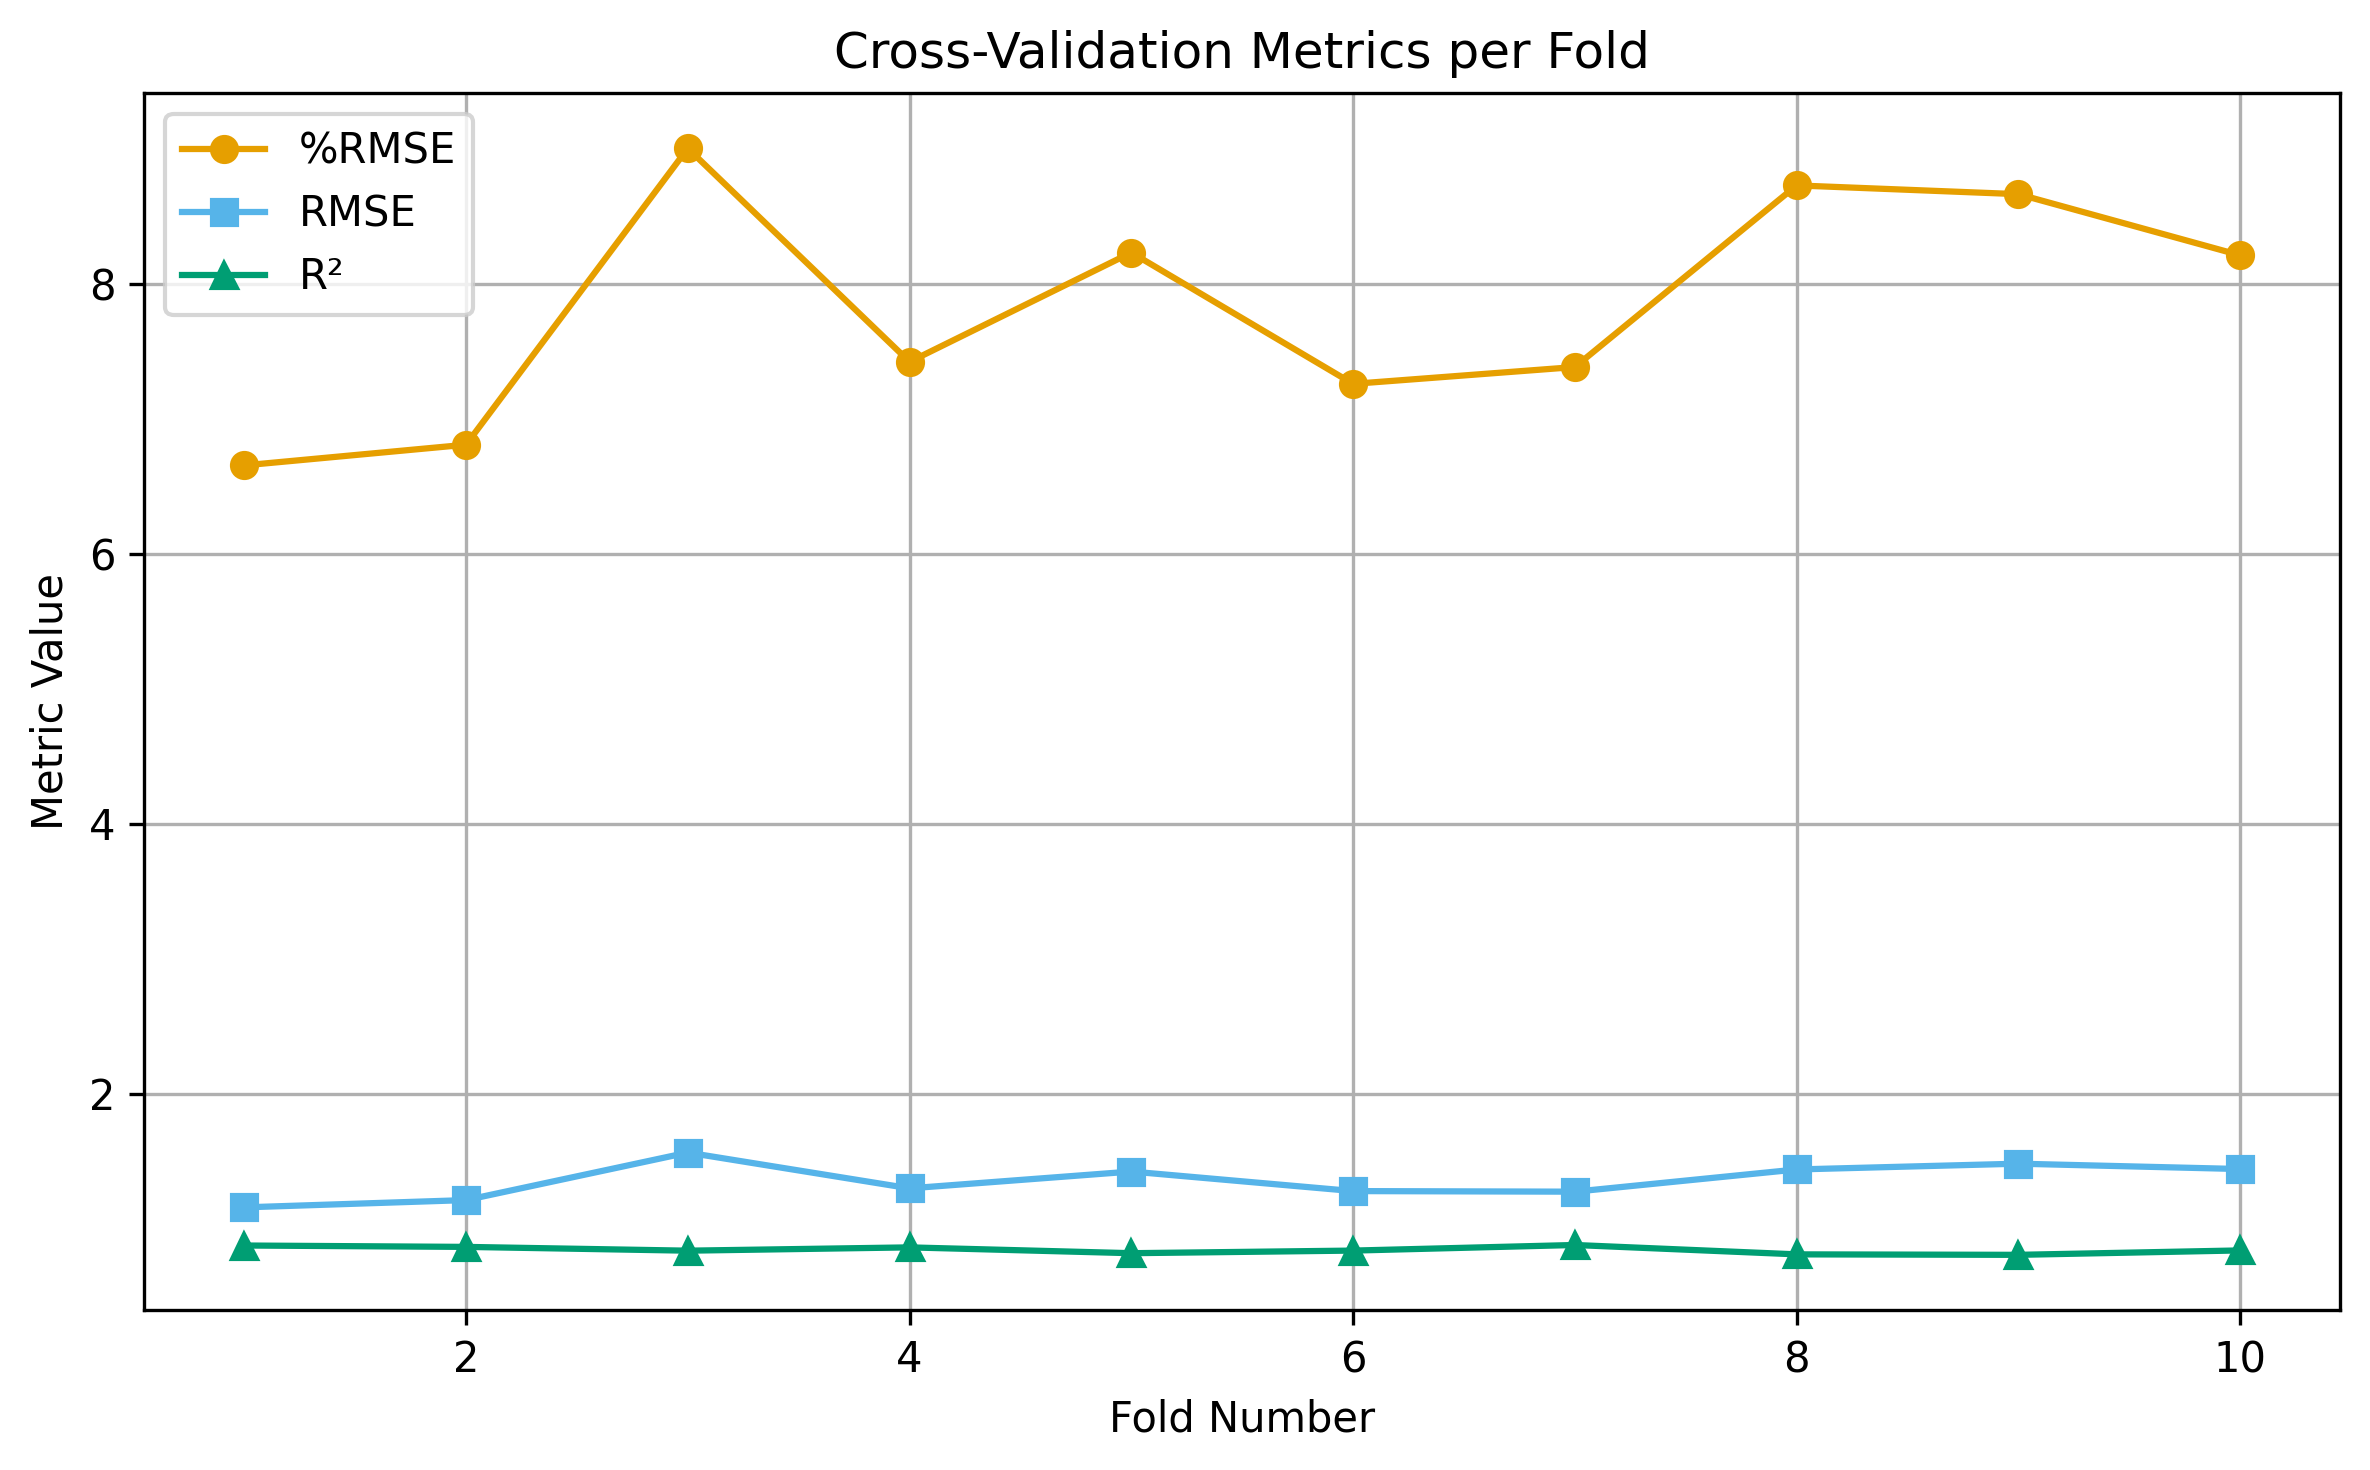

In [107]:
best_xgbr_model, results = eval_k_fold(best_xgbreg, X_all, y_all, 10)

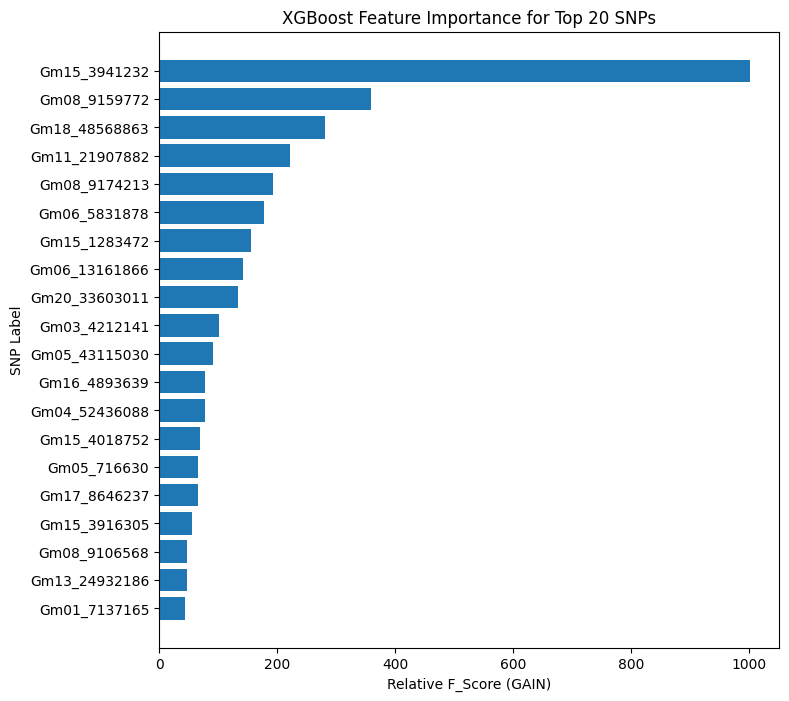

In [31]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, X_dupe, top_n=20, savepath="SNP_lasso_so_FI.png")

In [32]:
explainer = shap.Explainer(best_xgbr_model)

In [33]:
shap_values = explainer(X_dupe)

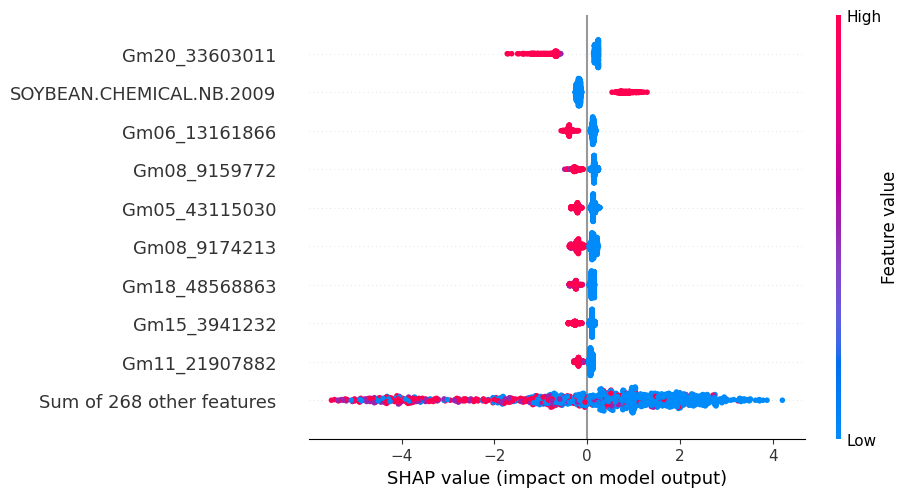

In [34]:
shap.plots.beeswarm(shap_values, show=False)
plt.savefig('SNP_lasso_so_shap.png', dpi=600, bbox_inches='tight')

In [95]:
holdout_data = pd.read_pickle("SNP_holdout_data.pkl")
holdout_data.head()

,Data-storage-ID,Gm01_3567,Gm01_3677,Gm01_7345,Gm01_7357,Gm01_8865,Gm01_8876,Gm01_10496,Gm01_11433,Gm01_13491,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
new_line,,,,,,,,,,,,,,,,,,,,,
HN009_SOYBEAN.EVALUATION.5IL90,HN009,0,0,1,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,16.8
HN010_SOYBEAN.EVALUATION.4IL87,HN010,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,18.3
HN015_SOYBEAN.EVALUATION.3IL83.2,HN015,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,15.0
HN017B_SOYBEAN.EVALUATION.3IL83.2,HN017B,0,0,0,1,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,15.5
HN023_SOYBEAN.EVALUATION.2IL81.2,HN023,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,15.6


In [96]:
holdout_data = holdout_data.set_index('Data-storage-ID')

In [97]:
holdout_data.head()

,Gm01_3567,Gm01_3677,Gm01_7345,Gm01_7357,Gm01_8865,Gm01_8876,Gm01_10496,Gm01_11433,Gm01_13491,Gm01_15043,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,0,0,1,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,16.8
HN010,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,18.3
HN015,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,15.0
HN017B,0,0,0,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,15.5
HN023,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,15.6


In [98]:
X_holdout = holdout_data.iloc[:, 0:538334]
X_holdout.head()

,Gm01_3567,Gm01_3677,Gm01_7345,Gm01_7357,Gm01_8865,Gm01_8876,Gm01_10496,Gm01_11433,Gm01_13491,Gm01_15043,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,0,0,1,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN010,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
HN015,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
HN017B,0,0,0,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
HN023,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [99]:
y_holdout = holdout_data.iloc[:, 538334:]
y_holdout.head()

,seed_oil
Data-storage-ID,
HN009,16.8
HN010,18.3
HN015,15.0
HN017B,15.5
HN023,15.6


In [100]:
X_dupe.head()

,Gm01_782148,Gm01_1381480,Gm01_2611788,Gm01_4432828,Gm01_7137165,Gm01_7544276,Gm01_8931835,Gm01_34025243,Gm01_46985479,Gm01_47028050,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
new_line,,,,,,,,,,,,,,,,,,,,,
AB-01_SOYBEAN.EVALUATION.4IL87,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
AB-02_SOYBEAN.EVALUATION.MS2001_02,2,0,0,0,2,2,2,0,0,0,...,0,0,1,0,0,0,0,0,0,0
BR-24_SOYBEAN.CHEMICAL.NB.2009,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,0
ESS_SOYBEAN.CHEMICAL.NB.2009,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,0
ESS_SOYBEAN.EVALUATION.5IL90,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,0


In [101]:
X_dupe, X_holdout = X_dupe.align(X_holdout, join='inner', axis=1)

In [102]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128 entries, HN009 to USB-803
Columns: 277 entries, Gm01_782148 to WILD.SOYBEAN.EVAL.1IL85
dtypes: int64(277)
memory usage: 278.0+ KB


In [103]:
y_holdout.shape

(128, 1)

In [104]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.85
RMSE of Holdout: 1.40
Mean of Holdout: 16.91
This is 8.29% of the mean pheno data
0 16.8 18.933992
1 18.3 16.549587
2 15.0 15.248295
3 15.5 16.302628
4 15.6 15.055679


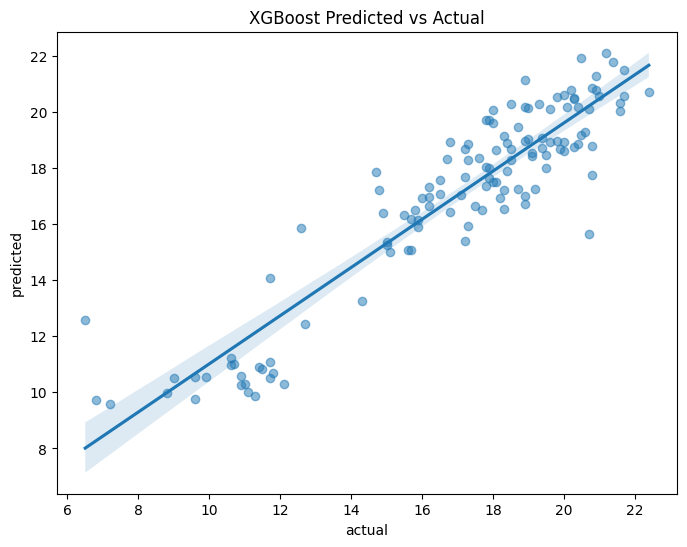

In [105]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [108]:
pickle.dump(best_xgbr_model, open("lasso_snp.pickle.dat", "wb"))

In [30]:
best_xgbr_model = pickle.load(open("best_models/lasso_snp.pickle.dat", "rb"))